### Assignment 1

Submission should be in a Jupyter note book (.ipynb)

1. Implement a function that converts a ```fixed<w, b>``` representation to a real number. Use two's compement for negative numbers. The function signature is

   ```python
   def fromFixedPoint(w: int, b:int, bits:[int]) -> float:
   # w: width of the binary representation
   # b: binary point
   ```
   Test the following inputs
   ```python
   fromFixedPoint(10, 3, [0, 1, 0, 1, 1, 0, 0, 1, 1, 0])
   ```
   ```python
   fromFixedPoint(10, 5, [1, 0, 0, 1, 0, 1, 0, 1, 1, 1])
   ```
   ```python
   fromFixedPoint(8, 2, [1, 0, 1, 0, 1, 0, 1, 1])
   ```
   


In [14]:
# WORKING
# w=8
# b=2
# bits = [1, 0, 1, 0, 1, 0, 1, 1]
# value = 0
# for i in range(1, w):
#   value += bits[i] * (2 ** (w-b-1-i))

# print (value)

# if bits[0] == 1:
#   value -= bits[0]*(2**(w-1-b))

# print (value)

10.75
-21.25


In [16]:
def fromFixedPoint(w: int, b: int, bits: [int]) -> float:
    if len(bits) != w:
        raise ValueError("The length of the bit array must match the specified width (w).")

    if b<0:
      raise ValueError("b must be 0 or a positive number.")

    if set(bits) <= {0, 1}:
      print ("The entered bits are correct")
    else:
      raise ValueError("The entered bits are wrong. Please try again.")


    value = 0
    for i in range(1, w):
      value += bits[i] * (2 ** (w-b-1-i))

    if bits[0] == 1:
      value -= bits[0]*(2**(w-1-b))
    return value

# Functions correctly:
fromFixedPoint(10, 3, [0, 1, 0, 1, 1, 0, 0, 1, 1, 0]) #Answer 44.75

fromFixedPoint(10, 5, [1, 0, 0, 1, 0, 1, 0, 1, 1, 1]) #Answer -13.28125

fromFixedPoint(8, 2, [1, 0, 1, 0, 1, 0, 1, 1]) #Answer -21.25

#Error checks
## for number of bits matches w:
###fromFixedPoint(10, 3, [0, 0, 1, 1, 0, 0, 1, 1, 0])

## for b>= 0
###fromFixedPoint(9, -3, [0, 0, 1, 1, 0, 0, 1, 1, 0])

## for bits only have 1 and 0
###fromFixedPoint(10, 3, [0, 2, 0, 1, 1, 0, 0, 1, 1, 0])

The entered bits are correct
The entered bits are correct
The entered bits are correct


-21.25

In [17]:
fromFixedPoint(10, 3, [0, 1, 0, 1, 1, 0, 0, 1, 1, 0])

The entered bits are correct


44.75

In [18]:
fromFixedPoint(10, 5, [1, 0, 0, 1, 0, 1, 0, 1, 1, 1])

The entered bits are correct


-13.28125

In [19]:
fromFixedPoint(8, 2, [1, 0, 1, 0, 1, 0, 1, 1])

The entered bits are correct


-21.25

2. Calculate the price of the following questions step by step using two step Cox Rox Rubinstein (CRR) Binomial tree

    a. European call option with $S = 100$, $K = 105$, $r = 3%$, $T=1$, $\sigma = 20%$
    
    b. European put option with $S = 100$, $K = 105$, $r = 3%$, $T=1$, $\sigma = 20%$
    
    c. European call option with $S = 100$, $K = 105$, $r = 3%$, $T=1$, $\sigma = 10%$
    
    d. European put option with $S = 100$, $K = 105$, $r = 3%$, $T=1$, $\sigma = 10%$
    
    What is the value of the portfolio that is long (a) and short (b)? How about the portfolio that long (c) and short (d)?

    Note: Don't use codes to generate numbers. Calcualte them manually.
    

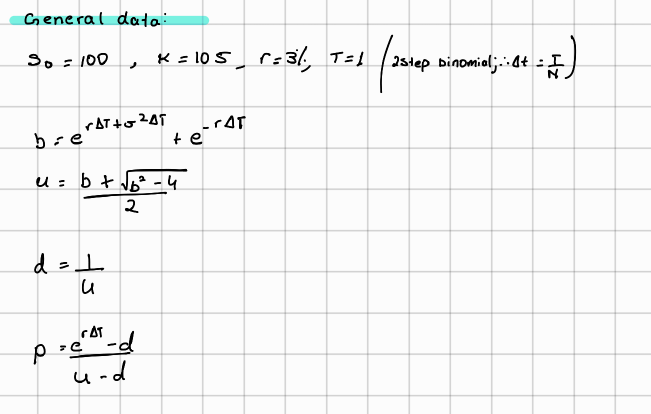

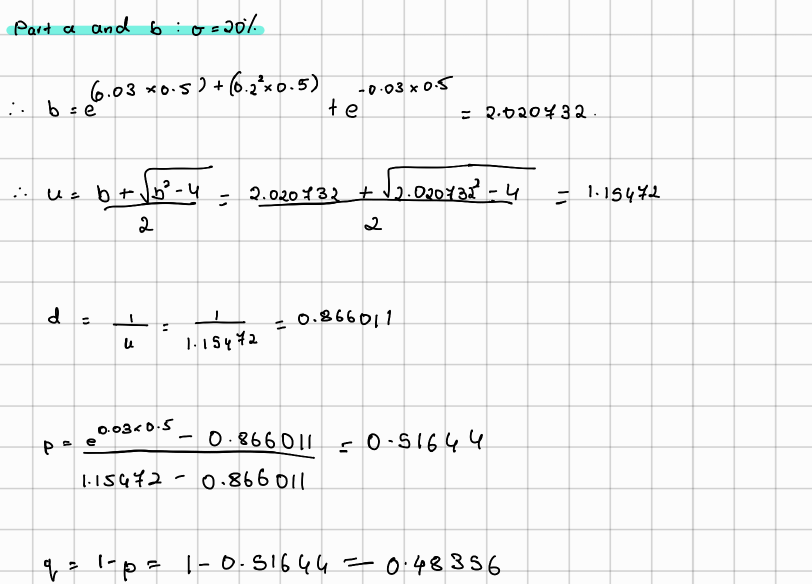

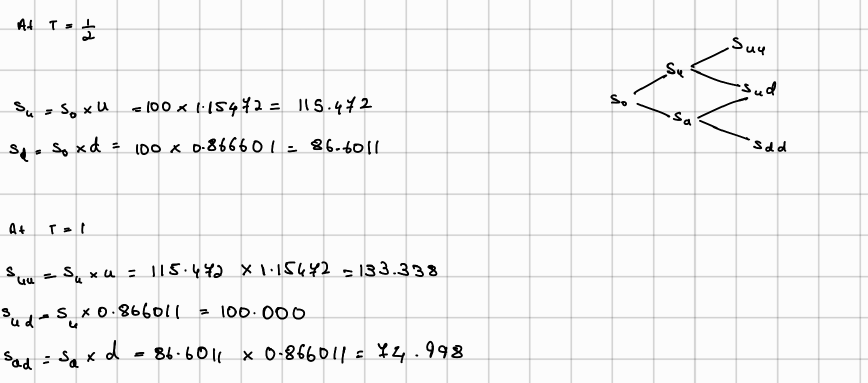

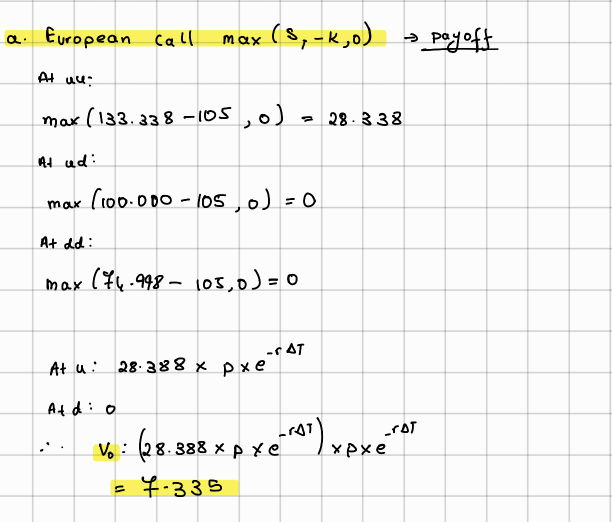

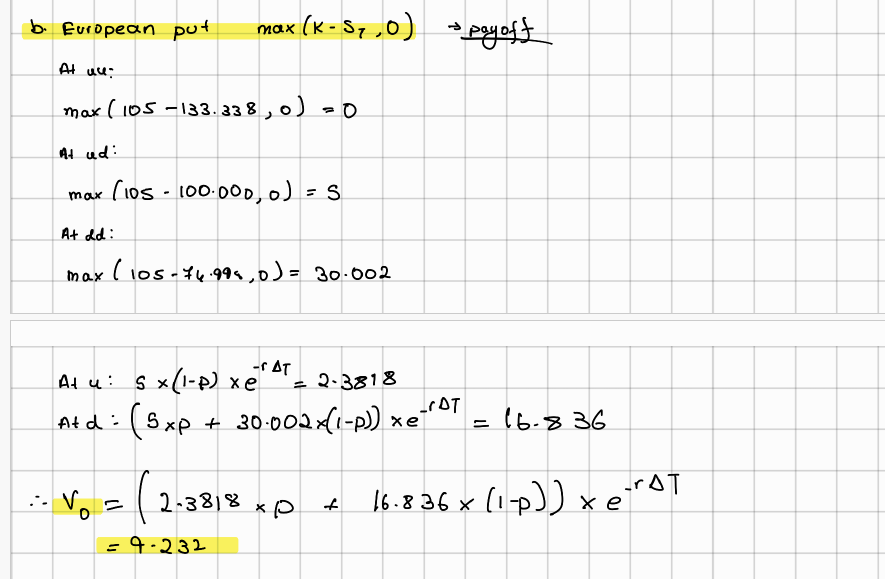

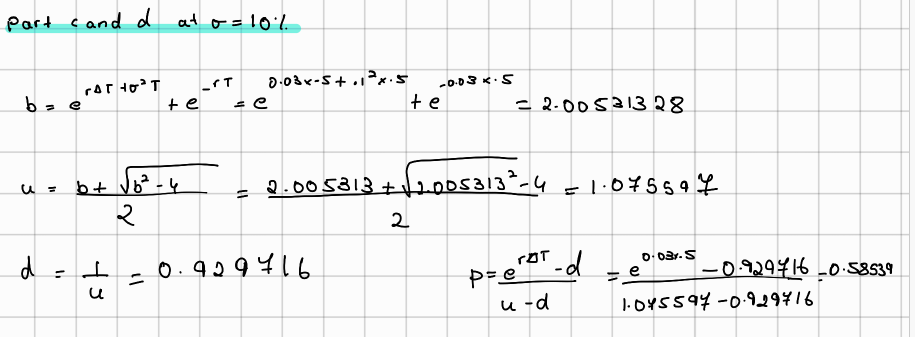

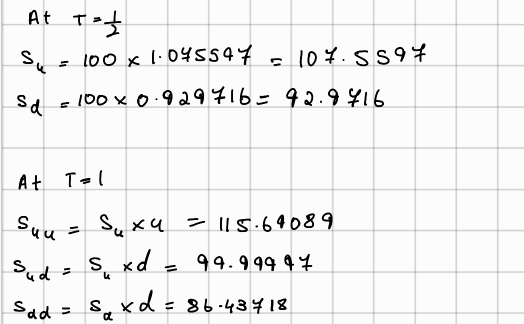

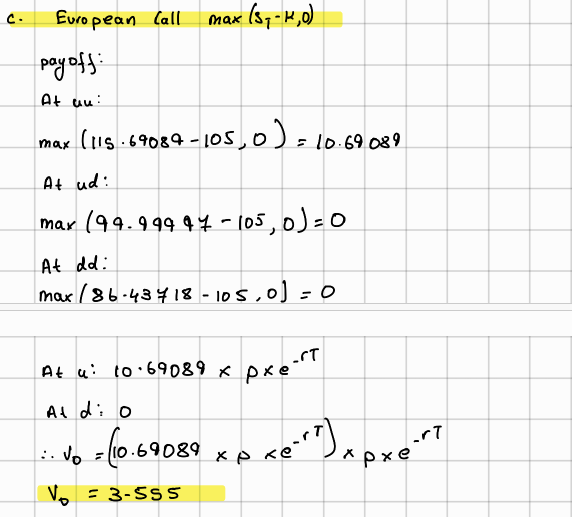

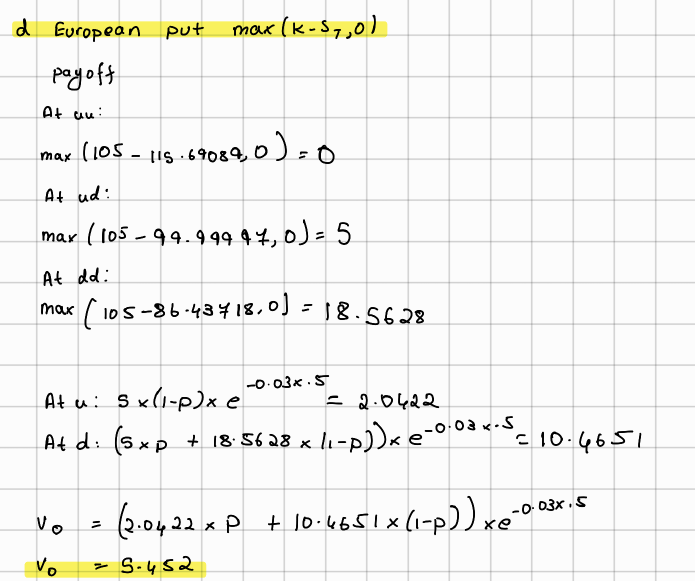

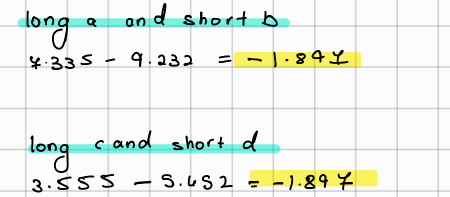

3. Greeks measure the sensitivity of the price of derivatives to a change in underlying asset’s parameters. They are used for hedging and risk
management. The commonly used greeks are:
    * Delta $\Delta = \frac{\partial V}{\partial S}$: measures the rate of change of the option value with respect to changes in the underlying asset's price.
    * Gamma $\Gamma = \frac{\partial^2 V}{\partial S^2} = \frac{\partial \Delta}{\partial S}$: measures the rate of change of delta with respect to changes in the underlying asset's price.
    * Vega: $v = \frac{\partial V}{\partial \sigma}$: measures the rate of change of the option value with respect to changes in the underlying asset's volatility.
    * Theta: $\theta = \frac{\partial V}{\partial t}$: the rate of change in the price of an option with respect to pricing time. Note that we normally use $t$ to represent pricing time, $T$ to represent expiry time, time to expiry in our pricer is $T-t$. In the implementation of the pricers that take time to expiry as an argument, we implicitly set pricing time to 0 (present).
    * Rho: the rate of change in the price of an option in response to a change in the interest rate.
    
  The greeks are normally not known in closed form since numerical pricers are used. They are approximated by finite differences:

  \begin{align}
    & \Delta = \frac{\partial V}{\partial S} \approx \frac{V(S + \Delta S) - V(S-\Delta S)}{2 \Delta S}, ~~~\Delta S = 0.1\% S \\
    & \Gamma = \frac{\partial V^2}{\partial S^2} \approx \frac{V(S + \Delta S) - 2V(S) + V(S-\Delta S)}{\Delta S^2} , ~~~ choose ~~~ \Delta S ~~~ appropriately!\\
    & v = \frac{\partial V}{\partial \sigma} \approx \frac{V(S, \sigma +\Delta \sigma) - V(S, \sigma -\Delta \sigma)}{2 \Delta \sigma } ~~~~~~~\Delta \sigma = 0.1\% \\
    & \theta = \frac{\partial V}{\partial t} \approx \frac{V(S, t+\Delta t, T) - V(S, t, T)}{\Delta t} ~~~~\Delta t = 0.004 \\
    & \rho = \frac{\partial V}{\partial r} \approx \frac{V(S, r+\Delta r) - V(S, r - \Delta r)}{2 \Delta r}  ~~~~~\Delta r = 0.0001
  \end{align}

  Implement a Greeks calculater for binomial tree pricer provided below. The signature of the greeks calculator is
      ```python
      def binomialGreeks(S, r, vol, T, strike, greekType) -> float
      ```
  Setting $S = 100, r = 0.03, vol = 0.2, t = 0, T = 1$, plot each greeks as a function of strike from 50 to 150. Play with different binomial models and see if there is any difference.
  
  Note that in practice, the greeks are rescaled with a pre-defined scaler, so that they give a sense of how much PV (Delta) changes with a typical move of the market. The rescaling is not incorporated in this exercise.

  Please only show one graph for each Greek for European and American put option.  Total 12 graphs : (price, delta, gamma, vega, theta, rho) *(European, American Put Option).

In [1]:
# binomial pricer for exercise 3
import math
from enum import Enum

class PayoffType(Enum):
    Call = 0
    Put = 1

class EuropeanOption():
    def __init__(self, expiry, strike, payoffType):
        self.expiry = expiry
        self.strike = strike
        self.payoffType = payoffType
    def payoff(self, S):
        if self.payoffType == PayoffType.Call:
            return max(S - self.strike, 0)
        elif self.payoffType == PayoffType.Put:
            return max(self.strike - S, 0)
        else:
            raise Exception("payoffType not supported: ", self.payoffType)
    def valueAtNode(self, t, S, continuation):
        return continuation

class AmericanOption():
    def __init__(self, expiry, strike, payoffType):
        self.expiry = expiry
        self.strike = strike
        self.payoffType = payoffType
    def payoff(self, S):
        if self.payoffType == PayoffType.Call:
            return max(S - self.strike, 0)
        elif self.payoffType == PayoffType.Put:
            return max(self.strike - S, 0)
        else:
            raise Exception("payoffType not supported: ", self.payoffType)
    def valueAtNode(self, t, S, continuation):
        return max(self.payoff(S), continuation)

def crrCalib(r, vol, t):
    b = math.exp(vol * vol * t + r * t) + math.exp(-r * t)
    u = (b + math.sqrt(b * b - 4)) / 2
    p = (math.exp(r * t) - (1 / u)) / (u - 1 / u)
    return (u, 1/u, p)

def jrrnCalib(r, vol, t):
    u = math.exp((r - vol * vol / 2) * t + vol * math.sqrt(t))
    d = math.exp((r - vol * vol / 2) * t - vol * math.sqrt(t))
    p = (math.exp(r * t) - d) / (u - d)
    return (u, d, p)

def jreqCalib(r, vol, t):
    u = math.exp((r - vol * vol / 2) * t + vol * math.sqrt(t))
    d = math.exp((r - vol * vol / 2) * t - vol * math.sqrt(t))
    return (u, d, 1/2)

def tianCalib(r, vol, t):
    v = math.exp(vol * vol * t)
    u = 0.5 * math.exp(r * t) * v * (v + 1 + math.sqrt(v*v + 2*v - 3))
    d = 0.5 * math.exp(r * t) * v * (v + 1 - math.sqrt(v*v + 2*v - 3))
    p = (math.exp(r * t) - d) / (u - d)
    return (u, d, p)

def binomialPricer(S, r, vol, trade, n, calib):
    t = trade.expiry / n
    (u, d, p) = calib(r, vol, t)
    # set up the last time slice, there are n+1 nodes at the last time slice
    vs = [trade.payoff(S * u ** (n - i) * d ** i) for i in range(n + 1)]
    # iterate backward
    for i in range(n - 1, -1, -1):
        # calculate the value of each node at time slide i, there are i nodes
        for j in range(i + 1):
            nodeS = S * u ** (i - j) * d ** j
            continuation = math.exp(-r * t) * (vs[j] * p + vs[j + 1] * (1 - p))
            vs[j] = trade.valueAtNode(t * i, nodeS, continuation)
    return vs[0]

In [2]:
def binomialGreeks(S, r, vol, T, strike, greekTyp, PayoffType, OptionType, Model):
    delta_S = S/1000
    delta_vol = 0.001
    delta_t = 0.004
    delta_r = 0.0001
    opt = OptionType(T,strike,PayoffType)
    n = 300
    if greekTyp == 'Delta':
        return (binomialPricer(S + delta_S,r,vol,opt,n,Model) - binomialPricer(S - delta_S,r,vol,opt,n,Model))/(2*delta_S)
    if greekTyp == 'Gamma':
        return (binomialPricer(S + delta_S,r,vol,opt,n,Model) + binomialPricer(S - delta_S,r,vol,opt,n,Model) - 2*binomialPricer(S,r,vol,opt,n,Model))/(delta_S ** 2)
    if greekTyp == 'Vega':
        return (binomialPricer(S,r,vol+delta_vol,opt,n,Model) - binomialPricer(S,r,vol-delta_vol,opt,n,Model))/(2* delta_vol)
    if greekTyp == 'Theta':
        return (binomialPricer(S,r,vol,OptionType(T+delta_t,strike,PayoffType),n,Model) - binomialPricer(S,r,vol,opt,n,Model))/delta_t
    if greekTyp == 'Rho':
        return (binomialPricer(S,r+delta_r,vol,opt,n,Model) - binomialPricer(S,r-delta_r,vol,opt,n,Model))/(2* delta_r)
    else:
        print('error')


In [3]:
# JUST WORKING

# import pandas as pd
# import matplotlib.pyplot as plt
# import plotly.graph_objects as go

# def plot_option_greeks(S, r, vol, T, strike_range, model_list, greekTyp, PayoffType, OptionType):
#     greek_data = pd.DataFrame({
#         f'{n}': [
#             binomialGreeks(S, r, vol, T, strike, greekTyp, PayoffType, OptionType, model)
#             for strike in strike_range
#         ] for n, model in enumerate(model_list)
#     })

#     greek_data.columns = ['crrCalib', 'jrrnCalib', 'jreqCalib', 'tianCalib']
#     greek_data.index = strike_range

#     # Create a plotly graph
#     fig = go.Figure()

#     # Add traces for each model
#     for model in greek_data.columns:
#         fig.add_trace(go.Scatter(
#             x=greek_data.index,
#             y=greek_data[model],
#             mode='lines',
#             name=model
#         ))

#     # Set plot title and labels
#     fig.update_layout(
#         title=f'{greekTyp} of {OptionType.__name__} with {PayoffType}',
#         xaxis_title='Strike Price',
#         yaxis_title=greekTyp,
#         showlegend=True
#     )

#     # Show the interactive plot
#     fig.show()

In [8]:
strike_range = range(50,150)
S = 100
r = 0.03
vol = 0.2
t = 0
T = 1
n=100
model_list = [crrCalib, jrrnCalib, jreqCalib, tianCalib]
model_names = ['CRR', 'JRRN', 'JREQ', 'Tian']

#Answer
`Put option`

##Price

In [13]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Prepare data for plotting
plot_data = []

# Loop through each model and generate put prices for all strikes
for model, model_name in zip(model_list, model_names):
    for strike in strike_range:
        put_price = binomialPricer(S, r, vol, EuropeanOption(T, strike, PayoffType.Put), n, model)

        plot_data.append({'strike': strike, 'price': put_price, 'option_type': 'Put', 'model': model_name})

# Convert data to a DataFrame for plotly
df = pd.DataFrame(plot_data)

# Create a figure with subplots for each model
fig = go.Figure()

# Add lines for each model's Put prices
for model_name in model_names:
    model_data = df[(df['model'] == model_name) & (df['option_type'] == 'Put')]

    fig.add_trace(go.Scatter(
        x=model_data['strike'],
        y=model_data['price'],
        mode='lines',
        name=f'{model_name} Put',
        line=dict(dash='dash')  # Dashed line for puts
    ))

# Update layout with title and labels
fig.update_layout(
    title='European Put Option Prices using Different Binomial Models',
    xaxis_title='Strike Price ($)',
    yaxis_title='Put Option Price ($)',
    legend_title='Option Type',
    template='plotly',
    width=1000,
    height=500
)

# Show the plot with interactive features
fig.show()


In [14]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Prepare data for plotting
plot_data = []

# Loop through each model and generate American put prices for all strikes
for model, model_name in zip(model_list, model_names):
    for strike in strike_range:
        put_price = binomialPricer(S, r, vol, AmericanOption(T, strike, PayoffType.Put), n, model)  # <-- Changed to AmericanOption

        plot_data.append({'strike': strike, 'price': put_price, 'option_type': 'Put', 'model': model_name})

# Convert data to a DataFrame for plotly
df = pd.DataFrame(plot_data)

# Create a figure with subplots for each model
fig = go.Figure()

# Add lines for each model's Put prices
for model_name in model_names:
    model_data = df[(df['model'] == model_name) & (df['option_type'] == 'Put')]

    fig.add_trace(go.Scatter(
        x=model_data['strike'],
        y=model_data['price'],
        mode='lines',
        name=f'{model_name} American Put',
        line=dict(dash='dash')  # Dashed line for puts
    ))

# Update layout with title and labels
fig.update_layout(
    title='American Put Option Prices using Different Binomial Models',
    xaxis_title='Strike Price ($)',
    yaxis_title='Put Option Price ($)',
    legend_title='Option Type',
    template='plotly',
    width=800,
    height=500
)

# Show the plot with interactive features
fig.show()


##Greeks

In [18]:
import pandas as pd
import plotly.graph_objects as go

def plot_put_options_greek(S, r, vol, T, strike_range, model_list, greekTyp, PayoffType, OptionType):
    # Create a figure for Plotly
    fig = go.Figure()

    # Compute Greek values only for Put options
    greek_data = pd.DataFrame({
        f'{n}': [
            binomialGreeks(S, r, vol, T, strike, greekTyp, PayoffType.Put, OptionType, model)
            for strike in strike_range
        ] for n, model in enumerate(model_list)
    })

    greek_data.columns = model_names
    greek_data.index = strike_range

    # Add traces for each model
    for model in greek_data.columns:
        fig.add_trace(go.Scatter(
            x=greek_data.index,
            y=greek_data[model],
            mode='lines',
            name=f'{model} - Put'
        ))

    # Set plot title and labels
    fig.update_layout(
        title=f'{greekTyp} of {OptionType.__name__} for Put Option',
        xaxis_title='Strike Price',
        yaxis_title=greekTyp,
        showlegend=True
    )

    # Show the interactive plot
    fig.show()


###Delta

In [19]:
plot_put_options_greek(S, r, vol, T, strike_range, model_list, "Delta", PayoffType, EuropeanOption)

In [20]:
plot_put_options_greek(S, r, vol, T, strike_range, model_list, "Delta", PayoffType, AmericanOption)

###Gamma

In [21]:
plot_put_options_greek(S, r, vol, T, strike_range, model_list, "Gamma", PayoffType, EuropeanOption)

In [22]:
plot_put_options_greek(S, r, vol, T, strike_range, model_list, "Gamma", PayoffType, AmericanOption)

###Vega

In [23]:
plot_put_options_greek(S, r, vol, T, strike_range, model_list, "Vega", PayoffType, EuropeanOption)

In [24]:
plot_put_options_greek(S, r, vol, T, strike_range, model_list, "Vega", PayoffType, AmericanOption)

###Theta

In [25]:
plot_put_options_greek(S, r, vol, T, strike_range, model_list, "Theta", PayoffType, EuropeanOption)

In [26]:
plot_put_options_greek(S, r, vol, T, strike_range, model_list, "Theta", PayoffType, AmericanOption)

###Rho

In [27]:
plot_put_options_greek(S, r, vol, T, strike_range, model_list, "Rho", PayoffType, EuropeanOption)

In [28]:
plot_put_options_greek(S, r, vol, T, strike_range, model_list, "Rho", PayoffType, AmericanOption)

#Just playing around with call and put (EXTRA)

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def plot_option_greeks(S, r, vol, T, strike_range, model_list, greekTyp, PayoffType, OptionType):
    # Create a figure for Plotly
    fig = go.Figure()

    # Loop over both Put and Call options
    for payoff_type in [PayoffType.Put, PayoffType.Call]:
        greek_data = pd.DataFrame({
            f'{n}': [
                binomialGreeks(S, r, vol, T, strike, greekTyp, payoff_type, OptionType, model)
                for strike in strike_range
            ] for n, model in enumerate(model_list)
        })

        greek_data.columns = model_names
        greek_data.index = strike_range

        # Add traces for each model
        for model in greek_data.columns:
            fig.add_trace(go.Scatter(
                x=greek_data.index,
                y=greek_data[model],
                mode='lines',
                name=f'{model} - {payoff_type}'
            ))

    # Set plot title and labels
    fig.update_layout(
        title=f'{greekTyp} of {OptionType.__name__} with PayoffType (Put and Call)',
        xaxis_title='Strike Price',
        yaxis_title=greekTyp,
        showlegend=True
    )

    # Show the interactive plot
    fig.show()



##Price

In [10]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Prepare data for plotting
plot_data = []

# Loop through each model and generate call and put prices for all strikes
for model, model_name in zip(model_list, model_names):
    for strike in strike_range:
        call_price = binomialPricer(S, r, vol, EuropeanOption(T, strike, PayoffType.Call), n, model)
        put_price = binomialPricer(S, r, vol, EuropeanOption(T, strike, PayoffType.Put), n, model)

        plot_data.append({'strike': strike, 'price': call_price, 'option_type': 'Call', 'model': model_name})
        plot_data.append({'strike': strike, 'price': put_price, 'option_type': 'Put', 'model': model_name})

# Convert data to a DataFrame for plotly
df = pd.DataFrame(plot_data)

# Create a figure with subplots for each model
fig = go.Figure()

# Add lines for each model's Call and Put prices
for model_name in model_names:
    for option_type in ['Call', 'Put']:
        model_data = df[(df['model'] == model_name) & (df['option_type'] == option_type)]

        fig.add_trace(go.Scatter(
            x=model_data['strike'],
            y=model_data['price'],
            mode='lines',
            name=f'{model_name} {option_type}',
            line=dict(dash='solid' if option_type == 'Call' else 'dash')
        ))

# Update layout with title and labels
fig.update_layout(
    title='Call and Put European Option Prices using Different Binomial Models',
    xaxis_title='Strike Price ($)',
    yaxis_title='Option Price ($)',
    legend_title='Option Type',
    template='plotly',
    width=800,
    height=500
)

# Show the plot with interactive features
fig.show()


In [11]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Prepare data for plotting
plot_data = []

# Loop through each model and generate call and put prices for all strikes
for model, model_name in zip(model_list, model_names):
    for strike in strike_range:
        # Calculate American option prices (using AmericanOption instead of EuropeanOption)
        call_price = binomialPricer(S, r, vol, AmericanOption(T, strike, PayoffType.Call), n, model)
        put_price = binomialPricer(S, r, vol, AmericanOption(T, strike, PayoffType.Put), n, model)

        plot_data.append({'strike': strike, 'price': call_price, 'option_type': 'Call', 'model': model_name})
        plot_data.append({'strike': strike, 'price': put_price, 'option_type': 'Put', 'model': model_name})

# Convert data to a DataFrame for plotly
df = pd.DataFrame(plot_data)

# Create a figure with subplots for each model
fig = go.Figure()

# Add lines for each model's Call and Put prices
for model_name in model_names:
    for option_type in ['Call', 'Put']:
        model_data = df[(df['model'] == model_name) & (df['option_type'] == option_type)]

        fig.add_trace(go.Scatter(
            x=model_data['strike'],
            y=model_data['price'],
            mode='lines',
            name=f'{model_name} {option_type}',
            line=dict(dash='solid' if option_type == 'Call' else 'dash')
        ))

# Update layout with title and labels
fig.update_layout(
    title='American Call and Put American Option Prices using Different Binomial Models',
    xaxis_title='Strike Price ($)',
    yaxis_title='Option Price ($)',
    legend_title='Option Type',
    template='plotly',
    width=800,
    height=500
)

# Show the plot with interactive features
fig.show()


##Delta


In [59]:
plot_option_greeks(S, r, vol, T, strike_range, model_list, 'Delta', PayoffType, EuropeanOption)


In [62]:
plot_option_greeks(S, r, vol, T, strike_range, model_list, 'Delta', PayoffType, AmericanOption)

##Gamma

In [90]:
plot_option_greeks(S, r, vol, T, strike_range, model_list, 'Gamma', PayoffType, EuropeanOption)

In [91]:
plot_option_greeks(S, r, vol, T, strike_range, model_list, 'Gamma', PayoffType, AmericanOption)

##Vega

In [92]:
plot_option_greeks(S, r, vol, T, strike_range, model_list, 'Vega', PayoffType, EuropeanOption)

In [93]:
plot_option_greeks(S, r, vol, T, strike_range, model_list, 'Vega', PayoffType, AmericanOption)

##Theta

In [94]:
plot_option_greeks(S, r, vol, T, strike_range, model_list, 'Theta', PayoffType, EuropeanOption)

In [95]:
plot_option_greeks(S, r, vol, T, strike_range, model_list, 'Theta', PayoffType, AmericanOption)

##Rho

In [96]:
plot_option_greeks(S, r, vol, T, strike_range, model_list, 'Rho', PayoffType, EuropeanOption)

In [97]:
plot_option_greeks(S, r, vol, T, strike_range, model_list, 'Rho', PayoffType, AmericanOption)